<a href="https://colab.research.google.com/github/xavierjacomep/curso-intro-machine-learning/blob/main/03_feature_engineering_tuning_hiperparametros_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#0F172A; padding:36px 48px;">
  <h1 style="color:#FFFFFF; font-size:2em; margin:0; font-weight:800; letter-spacing:1px;">
    🔧 FEATURE ENGINEERING Y OPTIMIZACIÓN DE HIPERPARÁMETROS
  </h1>
  <h2 style="color:#38BDF8; font-size:1.1em; margin:12px 0 6px 0; font-weight:400;">
    Caso Práctico: Valoración de Bienes Raíces (Sindian Dist., New Taipei City, Taiwán)
  </h2>
  <p style="color:#94A3B8; margin:0; font-size:0.95em;">
    Notebook 3 de 3 — Nivel: AVANZADO · Feature Engineering + 3 algoritmos + GridSearchCV
  </p>
</div>

---
## 🎯 Objetivo de este notebook

Este es el notebook más completo de los tres. Vamos a:

1. Reservar, desde el inicio, un **conjunto de prueba final (holdout)** que no se toca hasta
   el último paso — para evaluar el modelo elegido de forma honesta, sin fugas de información.
2. Medir un **baseline** (desempeño sin ningún feature engineering) con 3 algoritmos.
3. Aplicar 4 técnicas de **Feature Engineering**: creación de variables, transformación
   matemática, *binning* y selección de variables.
4. Medir el desempeño **con** Feature Engineering y comparar contra el baseline.
5. Afinar los hiperparámetros del mejor modelo con `GridSearchCV`, optimizando explícitamente
   la métrica más adecuada para este problema (RMSE).
6. Evaluar el modelo final, una sola vez, sobre el holdout.

**Algoritmos comparados en este notebook:** Regresión Lineal, Random Forest Regressor y
Gradient Boosting Regressor.

---
## 📦 Paso 0 — Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score, make_scorer
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

print("✅ Librerías importadas")

✅ Librerías importadas


---
## 📂 Paso 1 — Cargar datos y separar un holdout final

Repetimos la carga del dataset. Esta vez, **antes de hacer cualquier análisis o ajuste**,
separamos un 15% de los datos como **holdout final**: no se usará para explorar, entrenar,
seleccionar variables ni afinar hiperparámetros. Solo se usará **una vez**, al final, para
confirmar el desempeño real del modelo elegido — evitando así que el proceso de selección
"se entere" indirectamente de esos datos (fuga de información).

In [2]:
!pip install -q ucimlrepo
from ucimlrepo import fetch_ucirepo

real_estate = fetch_ucirepo(id=477)
df_original = pd.concat([real_estate.data.features, real_estate.data.targets], axis=1)

FEATURES_BASE = [
    'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station',
    'X4 number of convenience stores', 'X5 latitude', 'X6 longitude'
]
TARGET = 'Y house price of unit area'

df_work, df_holdout = train_test_split(
    df_original, test_size=0.15, random_state=RANDOM_STATE
)
df_work = df_work.reset_index(drop=True)
df_holdout = df_holdout.reset_index(drop=True)

print(f"Datos de trabajo (EDA + FE + CV + tuning): {df_work.shape[0]} filas")
print(f"Holdout final (solo evaluación final)    : {df_holdout.shape[0]} filas")

Datos de trabajo (EDA + FE + CV + tuning): 351 filas
Holdout final (solo evaluación final)    : 63 filas


---
## 📊 Paso 2 — Baseline: KPIs sin Feature Engineering

Antes de transformar nada, medimos el desempeño de **3 algoritmos** con los datos tal como
están. Este resultado es el piso que el Feature Engineering debe superar.

> Usamos validación cruzada K-Fold (5 folds) sobre `df_work`, para que la comparación sea
> justa y estable — igual que en el Notebook 2.

In [3]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def r2_ajustado_func(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

def hacer_scoring(n_features):
    # Usamos una función interna (closure) en vez de functools.partial: en versiones
    # recientes de scikit-learn (>=1.6), construir el repr() de un scorer cuyo score_func
    # es un functools.partial lanza AttributeError ('functools.partial' object has no
    # attribute '__name__'). Una función normal definida con `def` sí tiene __name__.
    def r2_ajustado_scorer(y_true, y_pred):
        return r2_ajustado_func(y_true, y_pred, n_features=n_features)

    return {
        'MAE':    'neg_mean_absolute_error',
        'RMSE':   'neg_root_mean_squared_error',
        'MAPE':   'neg_mean_absolute_percentage_error',
        'R2':     'r2',
        'R2_adj': make_scorer(r2_ajustado_scorer)
    }

def evaluar_cv(df, feature_list, target, label=""):
    # Entrena Regresión Lineal, Random Forest y Gradient Boosting con CV
    # y devuelve un DataFrame con MAE, RMSE, MAPE, R2 y R2 ajustado de cada uno.
    X = df[feature_list]
    y = df[target]

    scoring = hacer_scoring(n_features=len(feature_list))

    modelos = {
        'Regresión Lineal':  LinearRegression(),
        'Random Forest':     RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
        'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE)
    }

    filas = []
    for nombre, modelo in modelos.items():
        # ⚠️ Escalamos DENTRO de un Pipeline (no con scaler.fit_transform(X) antes de la CV):
        # así, cross_validate ajusta el StandardScaler en cada fold usando solo su porción de
        # entrenamiento, evitando que estadísticas del fold de validación se filtren al ajuste
        # (data leakage).
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('modelo', modelo)
        ])
        res = cross_validate(pipeline, X, y, cv=kfold, scoring=scoring)
        filas.append({
            'Escenario': label,
            'Modelo': nombre,
            'MAE':     -res['test_MAE'].mean(),
            'RMSE':    -res['test_RMSE'].mean(),
            'MAPE':    -res['test_MAPE'].mean() * 100,
            'R2':       res['test_R2'].mean(),
            'R2_adj':   res['test_R2_adj'].mean()
        })
    return pd.DataFrame(filas)

kpis_baseline = evaluar_cv(df_work, FEATURES_BASE, TARGET, label='Baseline (sin FE)')
kpis_baseline.round(4)

,Escenario,Modelo,MAE,RMSE,MAPE,R2,R2_adj
0,Baseline (sin FE),Regresión Lineal,6.3028,8.8597,19.1602,0.5711,0.5304
1,Baseline (sin FE),Random Forest,4.9937,7.7771,14.4100,0.6613,0.6291
2,Baseline (sin FE),Gradient Boosting,5.2029,8.1840,15.0036,0.6216,0.5857


---
## 🏗️ Paso 3 — FE Técnica 1: Creación de nuevos features

Construimos variables nuevas combinando o transformando la información original. Los datos
crudos a veces esconden patrones que el modelo no puede detectar directamente.

**Features que crearemos:**
- `house_age_sq`: la antigüedad al cuadrado, para capturar que el efecto de la antigüedad
  sobre el precio probablemente **no es lineal** (una vivienda de 0 a 5 años pierde valor más
  rápido que una de 30 a 35 años).
- `stores_per_age`: número de tiendas de conveniencia cercanas, relativizado por la antigüedad
  de la vivienda — una forma de capturar interacción entre desarrollo urbano y antigüedad.
- `trans_month_sin` / `trans_month_cos`: `X1 transaction date` incluye una parte fraccionaria
  que representa el mes de la transacción (ej. 2013.250 = marzo). Como los meses son cíclicos
  (diciembre está "cerca" de enero), los codificamos con seno y coseno en vez de usarlos como
  un número lineal.

In [4]:
def aplicar_feature_engineering(df):
    df = df.copy()

    # 1) Antigüedad al cuadrado
    df['house_age_sq'] = df['X2 house age'] ** 2

    # 2) Tiendas de conveniencia relativizadas por antigüedad
    df['stores_per_age'] = df['X4 number of convenience stores'] / (df['X2 house age'] + 1)

    # 3) Codificación cíclica del mes de transacción
    frac_mes = df['X1 transaction date'] % 1
    df['trans_month_sin'] = np.sin(2 * np.pi * frac_mes)
    df['trans_month_cos'] = np.cos(2 * np.pi * frac_mes)

    return df

df_fe = aplicar_feature_engineering(df_work)
FEATURES_NUEVOS_B1 = ['house_age_sq', 'stores_per_age', 'trans_month_sin', 'trans_month_cos']

df_fe[FEATURES_NUEVOS_B1].describe().round(3)

,house_age_sq,stores_per_age,trans_month_sin,trans_month_cos
count,351.000,351.000,351.000,351.000
mean,432.081,0.532,0.065,-0.087
std,463.345,1.135,0.666,0.740
min,0.000,0.000,-1.000,-1.000
25%,79.210,0.075,-0.498,-0.867
50%,259.210,0.213,0.000,-0.000
75%,739.850,0.439,0.498,0.867
max,1918.440,9.000,1.000,1.000


---
## 📐 Paso 4 — FE Técnica 2: Transformación matemática

`X3 distance to the nearest MRT station` suele tener una distribución muy **sesgada**: la
mayoría de viviendas están relativamente cerca del metro, pero unas pocas están extremadamente
lejos, distorsionando el aprendizaje de un modelo lineal.

Aplicamos una transformación logarítmica (`log1p`, que maneja bien el cero) para **comprimir**
los valores extremos y hacer la relación con el precio más lineal.

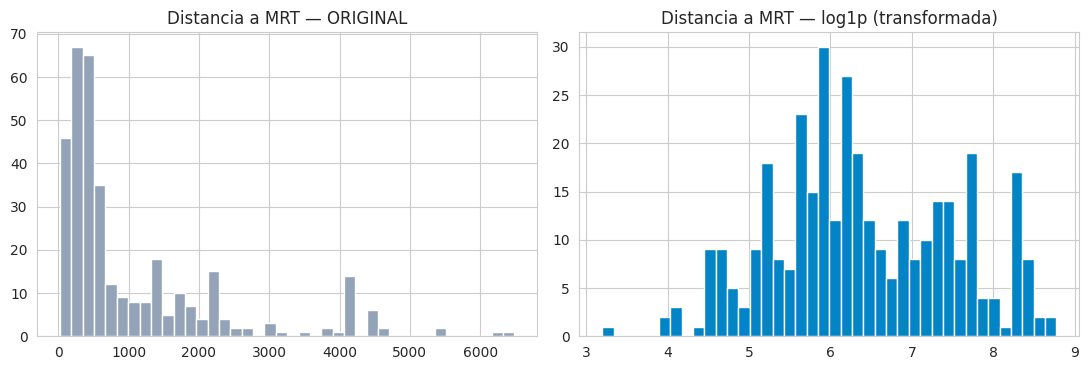

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(df_fe['X3 distance to the nearest MRT station'], bins=40, color='#94A3B8', edgecolor='white')
axes[0].set_title('Distancia a MRT — ORIGINAL')

df_fe['log_dist_mrt'] = np.log1p(df_fe['X3 distance to the nearest MRT station'])

axes[1].hist(df_fe['log_dist_mrt'], bins=40, color='#0284C7', edgecolor='white')
axes[1].set_title('Distancia a MRT — log1p (transformada)')

plt.tight_layout()
plt.show()

---
## 🗂️ Paso 5 — FE Técnica 3: Binning (discretización)

El *binning* convierte una variable numérica continua en categorías (bins). Es útil cuando la
relación entre la variable y el precio no es constante en todo el rango — por ejemplo, la
diferencia de precio entre una vivienda de 0 y 10 años puede ser mucho mayor que entre una de
30 y 40 años.

Creamos `AgeBand`: agrupa la antigüedad en 4 categorías (nueva, reciente, madura, antigua).

In [6]:
df_fe['AgeBand'] = pd.cut(
    df_fe['X2 house age'],
    bins=[-0.1, 5, 15, 30, 100],
    labels=[0, 1, 2, 3]   # 0=nueva, 1=reciente, 2=madura, 3=antigua
).astype(int)

print("Precio promedio por franja de antigüedad:")
print(df_fe.groupby('AgeBand')[TARGET].mean().round(2))

Precio promedio por franja de antigüedad:
AgeBand
0    47.13
1    39.46
2    32.42
3    37.84
Name: Y house price of unit area, dtype: float64


---
## 🎯 Paso 6 — FE Técnica 4: Selección de features con SelectKBest

Ya tenemos **más features de los que empezamos**. Pero más variables no siempre es mejor:
variables irrelevantes o redundantes pueden agregar ruido y perjudicar al modelo (especialmente
al modelo lineal).

`SelectKBest` con `f_regression` evalúa, de forma estadística, qué tan relacionada está cada
variable con el target (`Y house price of unit area`), y nos permite quedarnos solo con las
más relevantes.

In [7]:
FEATURES_NUEVOS_B2 = ['log_dist_mrt']
FEATURES_NUEVOS_B3 = ['AgeBand']

POOL_COMPLETO = FEATURES_BASE + FEATURES_NUEVOS_B1 + FEATURES_NUEVOS_B2 + FEATURES_NUEVOS_B3
# Quitamos duplicados manteniendo el orden
POOL_COMPLETO = list(dict.fromkeys(POOL_COMPLETO))

scaler_sel = StandardScaler()
X_pool_scaled = scaler_sel.fit_transform(df_fe[POOL_COMPLETO])

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_pool_scaled, df_fe[TARGET])

scores_df = pd.DataFrame({
    'Feature': POOL_COMPLETO,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)
scores_df['Relevante (p<0.05)'] = scores_df['p-value'] < 0.05

scores_df.round(4)

,Feature,F-Score,p-value,Relevante (p<0.05)
10,log_dist_mrt,399.8049,0.0000,True
2,X3 distance to the nearest MRT station,272.0271,0.0000,True
3,X4 number of convenience stores,157.7074,0.0000,True
4,X5 latitude,128.6455,0.0000,True
5,X6 longitude,117.4742,0.0000,True
7,stores_per_age,66.4094,0.0000,True
11,AgeBand,22.5518,0.0000,True
1,X2 house age,18.3417,0.0000,True
6,house_age_sq,4.2946,0.0390,True
8,trans_month_sin,3.1838,0.0752,False


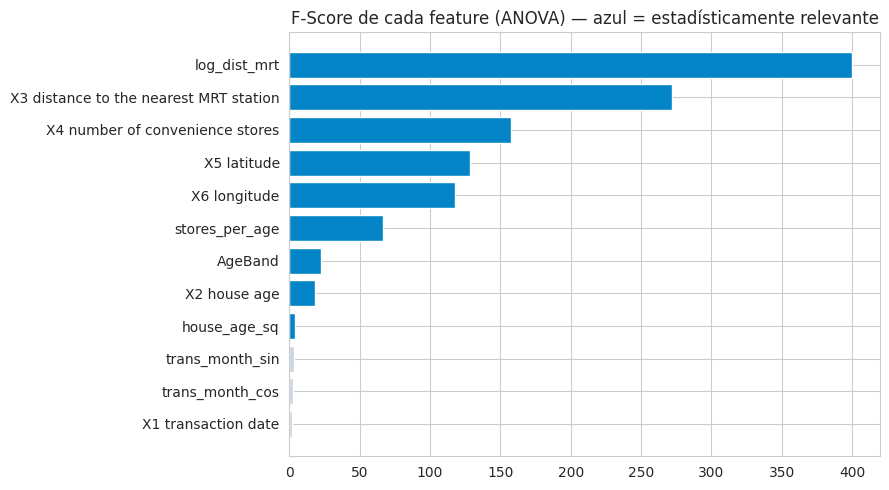

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

features_sorted = scores_df['Feature'].tolist()
fscores_sorted   = scores_df['F-Score'].tolist()
relevante        = scores_df['Relevante (p<0.05)'].tolist()
colores          = ['#0284C7' if r else '#CBD5E1' for r in relevante]

ax.barh(features_sorted, fscores_sorted, color=colores)
ax.invert_yaxis()
ax.set_title('F-Score de cada feature (ANOVA) — azul = estadísticamente relevante')
plt.tight_layout()
plt.show()

In [9]:
# Nos quedamos con los features estadísticamente significativos (p < 0.05)
FEATURES_FINAL = scores_df.loc[scores_df['Relevante (p<0.05)'], 'Feature'].tolist()

print(f"Features seleccionados ({len(FEATURES_FINAL)} de {len(POOL_COMPLETO)}):")
print(FEATURES_FINAL)

Features seleccionados (9 de 12):
['log_dist_mrt', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'stores_per_age', 'AgeBand', 'X2 house age', 'house_age_sq']


---
## 📊 Paso 7 — KPIs con Feature Engineering

Ahora medimos el desempeño de los mismos 3 modelos, con las mismas condiciones (CV 5-fold),
pero usando el conjunto de features enriquecido y seleccionado en el paso anterior.

In [10]:
kpis_fe = evaluar_cv(df_fe, FEATURES_FINAL, TARGET, label='Con Feature Engineering')
kpis_fe.round(4)

,Escenario,Modelo,MAE,RMSE,MAPE,R2,R2_adj
0,Con Feature Engineering,Regresión Lineal,5.2824,7.9272,15.4548,0.6488,0.5964
1,Con Feature Engineering,Random Forest,5.0258,7.6670,14.5158,0.6682,0.6186
2,Con Feature Engineering,Gradient Boosting,5.0826,7.8643,14.5738,0.6443,0.5912


---
## 📈 Paso 8 — Comparación visual: antes vs. después del Feature Engineering

Ponemos ambos escenarios frente a frente para responder la pregunta central:
**¿mejoró el desempeño de los modelos al aplicar Feature Engineering?**

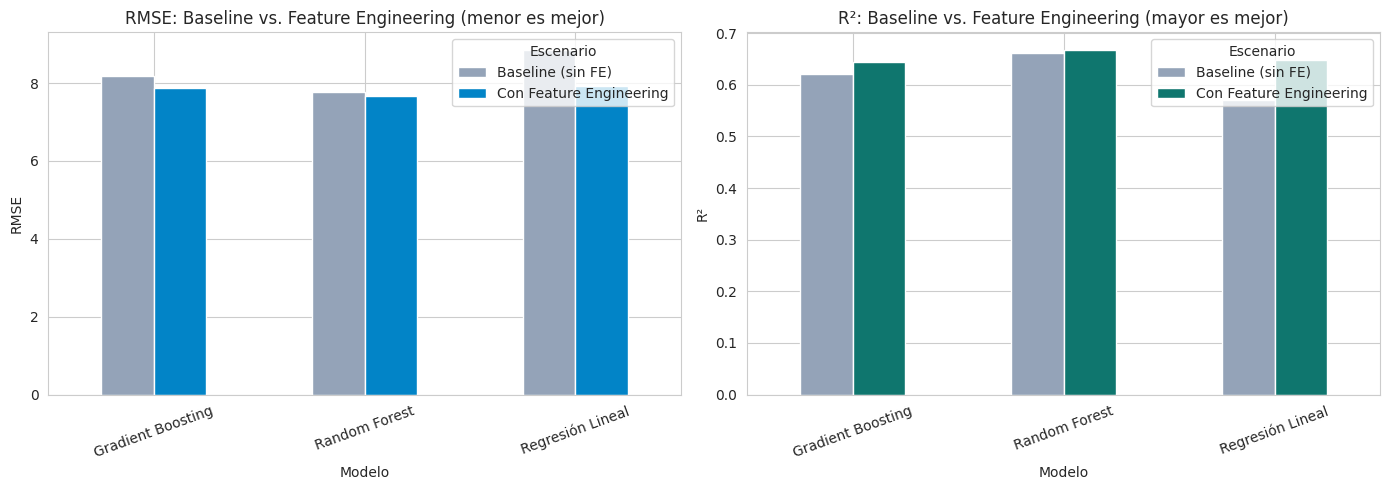

Escenario,Baseline (sin FE),Con Feature Engineering
Modelo,,
Gradient Boosting,8.184,7.864
Random Forest,7.777,7.667
Regresión Lineal,8.860,7.927


In [11]:
comparacion = pd.concat([kpis_baseline, kpis_fe], ignore_index=True)
comparacion_pivot_rmse = comparacion.pivot(index='Modelo', columns='Escenario', values='RMSE')
comparacion_pivot_r2   = comparacion.pivot(index='Modelo', columns='Escenario', values='R2')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparacion_pivot_rmse.plot(kind='bar', ax=axes[0], color=['#94A3B8', '#0284C7'])
axes[0].set_title('RMSE: Baseline vs. Feature Engineering (menor es mejor)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)

comparacion_pivot_r2.plot(kind='bar', ax=axes[1], color=['#94A3B8', '#0F766E'])
axes[1].set_title('R²: Baseline vs. Feature Engineering (mayor es mejor)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

comparacion_pivot_rmse.round(3)

---
## 🛠️ Paso 9 — Optimización de hiperparámetros con GridSearchCV

Elegimos el modelo con **mejor RMSE promedio** en el paso anterior y afinamos sus
hiperparámetros con `GridSearchCV`.

> **¿Por qué optimizamos usando RMSE y no MAE, MAPE o R²?**
> `GridSearchCV` necesita un único criterio ("scoring") para decidir qué combinación de
> hiperparámetros es la mejor. Usamos **RMSE** porque:
> - Es diferenciable y sensible a errores grandes — coherente con el costo real de un error
>   grande de valoración.
> - Está en las mismas unidades que el precio, fácil de interpretar.
> - Es el estándar de facto para optimizar modelos de regresión en la práctica.
>
> (`sklearn` provee `'neg_root_mean_squared_error'`, negativo porque `GridSearchCV` siempre
> **maximiza** el score — maximizar el negativo del RMSE equivale a minimizar el RMSE.)

In [12]:
modelo_ganador = comparacion_pivot_rmse['Con Feature Engineering'].idxmin()
print(f"🏆 Modelo con mejor RMSE (Feature Engineering): {modelo_ganador}")

🏆 Modelo con mejor RMSE (Feature Engineering): Random Forest


In [13]:
X_final = df_fe[FEATURES_FINAL]
y_final = df_fe[TARGET]

# Grillas de hiperparámetros específicas para cada algoritmo posible. GridSearchCV debe
# afinar el modelo que REALMENTE ganó en el paso anterior (`modelo_ganador`), no un modelo
# fijo de antemano — de lo contrario podríamos terminar optimizando (y reportando en el
# holdout) un algoritmo distinto al que la comparación de la Sección 7 identificó como mejor.
# Los nombres de los hiperparámetros llevan el prefijo 'modelo__' porque el estimador real
# usado por GridSearchCV es un Pipeline (ver más abajo).
grillas_por_modelo = {
    'Regresión Lineal': {
        'estimator': LinearRegression(),
        'param_grid': {}  # OLS no tiene hiperparámetros relevantes que afinar aquí
    },
    'Random Forest': {
        'estimator': RandomForestRegressor(random_state=RANDOM_STATE),
        'param_grid': {
            'modelo__n_estimators':     [200, 400],
            'modelo__max_depth':        [None, 8, 12],
            'modelo__min_samples_leaf': [1, 2, 4]
        }
    },
    'Gradient Boosting': {
        'estimator': GradientBoostingRegressor(random_state=RANDOM_STATE),
        'param_grid': {
            'modelo__n_estimators':  [100, 200, 400],
            'modelo__max_depth':     [2, 3, 4],
            'modelo__learning_rate': [0.01, 0.05, 0.1]
        }
    }
}

config_ganador = grillas_por_modelo[modelo_ganador]

# ⚠️ Igual que en evaluar_cv(): el escalador va DENTRO del Pipeline que se pasa a
# GridSearchCV, en vez de escalar X_final una sola vez antes de afinar. Así, cada
# combinación de hiperparámetros se evalúa con un escalador ajustado por fold, sin fuga
# de datos entre folds de la búsqueda de hiperparámetros.
pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', config_ganador['estimator'])
])

grid_search = GridSearchCV(
    estimator=pipeline_final,
    param_grid=config_ganador['param_grid'],
    scoring='neg_root_mean_squared_error',
    cv=kfold,
    n_jobs=-1
)

grid_search.fit(X_final, y_final)

print(f"Modelo afinado: {modelo_ganador}")
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print()
print(f"Mejor RMSE (promedio CV): {-grid_search.best_score_:.3f}")

Modelo afinado: Random Forest
Mejores hiperparámetros encontrados:
{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 4, 'modelo__n_estimators': 400}

Mejor RMSE (promedio CV): 7.367


---
## ✅ Paso 10 — Evaluación final sobre el holdout

Este es el **único** momento en que tocamos el holdout separado en el Paso 1. Entrenamos el
modelo final (con los mejores hiperparámetros encontrados) sobre **todos** los datos de
trabajo (`df_work` + Feature Engineering), y lo evaluamos, una sola vez, sobre el holdout.

In [14]:
# Aplicar el mismo Feature Engineering al holdout
df_holdout_fe = aplicar_feature_engineering(df_holdout)
df_holdout_fe['log_dist_mrt'] = np.log1p(df_holdout_fe['X3 distance to the nearest MRT station'])
df_holdout_fe['AgeBand'] = pd.cut(
    df_holdout_fe['X2 house age'],
    bins=[-0.1, 5, 15, 30, 100],
    labels=[0, 1, 2, 3]
).astype(int)

X_holdout = df_holdout_fe[FEATURES_FINAL]
y_holdout = df_holdout_fe[TARGET]

# modelo_final es el Pipeline completo (scaler + modelo optimizado): no hace falta
# transformar X_holdout a mano, el propio Pipeline aplica el StandardScaler ya ajustado
# sobre los datos de trabajo (df_work + FE), exactamente igual que haría con datos nuevos.
modelo_final = grid_search.best_estimator_
y_pred_holdout = modelo_final.predict(X_holdout)

mae_h  = mean_absolute_error(y_holdout, y_pred_holdout)
mse_h  = mean_squared_error(y_holdout, y_pred_holdout)
rmse_h = np.sqrt(mse_h)
mape_h = mean_absolute_percentage_error(y_holdout, y_pred_holdout) * 100
r2_h   = r2_score(y_holdout, y_pred_holdout)
n_h, p_h = X_holdout.shape[0], X_holdout.shape[1]
r2_adj_h = 1 - (1 - r2_h) * (n_h - 1) / (n_h - p_h - 1)

print("=" * 50)
print("  DESEMPEÑO FINAL SOBRE EL HOLDOUT (nunca antes visto)")
print("=" * 50)
print(f"  Modelo       : {modelo_ganador} optimizado")
print(f"  MAE          : {mae_h:.3f}")
print(f"  RMSE         : {rmse_h:.3f}   ⭐ métrica principal")
print(f"  MAPE         : {mape_h:.2f}%")
print(f"  R²           : {r2_h:.4f}")
print(f"  R² ajustado  : {r2_adj_h:.4f}")
print("=" * 50)

  DESEMPEÑO FINAL SOBRE EL HOLDOUT (nunca antes visto)
  Modelo       : Random Forest optimizado
  MAE          : 3.746
  RMSE         : 5.881   ⭐ métrica principal
  MAPE         : 11.03%
  R²           : 0.8055
  R² ajustado  : 0.7725


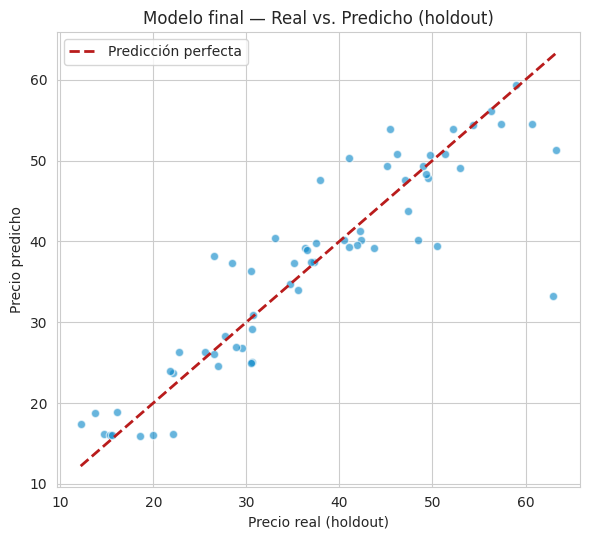

In [15]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(y_holdout, y_pred_holdout, alpha=0.6, color='#0284C7', edgecolor='white')
lims = [min(y_holdout.min(), y_pred_holdout.min()), max(y_holdout.max(), y_pred_holdout.max())]
ax.plot(lims, lims, '--', color='#B91C1C', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('Precio real (holdout)')
ax.set_ylabel('Precio predicho')
ax.set_title('Modelo final — Real vs. Predicho (holdout)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 📌 Paso 11 — Conclusiones y lecciones aprendidas

| Técnica | ¿Qué hicimos? | ¿Por qué funciona? |
|---|---|---|
| **Creación de features** | `house_age_sq`, `stores_per_age`, `trans_month_sin/cos` | Captura relaciones no lineales y cíclicas que el modelo no puede inferir directamente de las variables originales |
| **Transformación logarítmica** | `log_dist_mrt` | Reduce el efecto de valores extremos (distancias muy grandes al metro) y hace la relación con el precio más lineal |
| **Binning** | `AgeBand` | Captura que el efecto de la antigüedad sobre el precio no es constante en todo el rango |
| **Selección de features** | `SelectKBest` (`f_regression`) | Evita que variables irrelevantes o redundantes agreguen ruido al modelo |
| **GridSearchCV** | Afinó `n_estimators`, `max_depth`, `min_samples_leaf` optimizando RMSE | Encuentra la combinación de hiperparámetros que minimiza el error más costoso para el negocio |

### Resumen comparativo de los 3 notebooks

| Notebook | Nivel | Algoritmos | Validación | Resultado clave |
|---|---|---|---|---|
| 01 — Regresión simple | Básico | Regresión Lineal | 1 split 80/20 | Pipeline mínimo funcionando, todas las métricas calculadas |
| 02 — CV y comparación | Intermedio | Regresión Lineal + Random Forest | K-Fold (5) | Estimación más confiable del error; primer modelo no lineal |
| 03 — FE y tuning | Avanzado | Regresión Lineal + Random Forest + Gradient Boosting | K-Fold (5) + holdout final | Mejora vía Feature Engineering + modelo final optimizado y evaluado honestamente |

### Reflexión final
- La métrica que usamos consistentemente para **optimizar y comparar** modelos fue el
  **RMSE**, por estar en las unidades del precio y penalizar fuertemente los errores grandes.
- **R²** y **R² ajustado** se usaron como apoyo para comunicar, de forma interpretable, qué
  tan bien el modelo explica la variabilidad del precio.
- **MAE** y **MAPE** son útiles para comunicar resultados a audiencias no técnicas
  ("en promedio nos equivocamos en X" / "en promedio nos equivocamos Y%").
- El Feature Engineering no siempre garantiza una mejora enorme, pero sí debe evaluarse
  siempre de forma rigurosa (mismo esquema de CV, mismas condiciones) antes de decidir si
  vale la pena la complejidad adicional que introduce.

In [16]:
print("=" * 55)
print("  RESUMEN FINAL DEL PROYECTO")
print("=" * 55)
print(f"  Dataset          : Real Estate Valuation (UCI) — {len(df_original)} transacciones")
print(f"  Algoritmos usados: Regresión Lineal, Random Forest, Gradient Boosting")
print(f"  Modelo final     : {modelo_ganador} (hiperparámetros optimizados)")
print(f"  RMSE holdout     : {rmse_h:.3f}")
print(f"  R²   holdout     : {r2_h:.4f}")
print("=" * 55)

  RESUMEN FINAL DEL PROYECTO
  Dataset          : Real Estate Valuation (UCI) — 414 transacciones
  Algoritmos usados: Regresión Lineal, Random Forest, Gradient Boosting
  Modelo final     : Random Forest (hiperparámetros optimizados)
  RMSE holdout     : 5.881
  R²   holdout     : 0.8055
